# Week 8 - Evaluation Expansion

**Decision focus:** pricing review.

**Main conclusion:** on the comparable **June in-range** population, the model is useful for routine pricing review, but confidence is not equal across the market. Middle-price homes are more reliable; the lowest and highest bands need stronger human review before pricing action.

## 1. What This Evaluation Answers

Week 8 expands evaluation beyond R2 by adding **MAPE** and **MdAPE**.

The business question is simple: **where can the model support pricing confidence, and where should agents slow down for manual review?**

## 2. Assumptions

- Population: CRMLS residential **SingleFamilyResidence** closed sales.
- Main evaluation: **June in-range**, using training-defined ClosePrice and price-per-sqft limits.
- Robustness check: **Full June** is reported separately and should not be used as the main comparison.
- Error definition: prediction minus actual close price.
- MAPE and MdAPE are used because percentage error is easier to interpret across different price levels.
- Price bands are inherited from train-defined ClosePrice quantiles, so the test set does not define its own bands.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

ROOT = Path.cwd().parent if Path.cwd().name == "week8" else Path.cwd()
sys.path.insert(0, str(ROOT / "scripts"))

from week8_evaluation import build_metrics_summary, readable_summary

sns.set_theme(style="whitegrid")

## 3. Build the Metrics Summary

In [2]:
metrics = build_metrics_summary(ROOT)
summary = readable_summary(metrics)

display(
    metrics.assign(
        r2=metrics["r2"].round(3),
        mape=(metrics["mape"] * 100).round(2),
        mdape=(metrics["mdape"] * 100).round(2),
        p90_ape=(metrics["p90_ape"] * 100).round(2),
        mae=metrics["mae"].round(0),
        rmse=metrics["rmse"].round(0),
    )
)

,section,price_segment,rows,median_close_price,r2,mae,rmse,mape,mdape,p90_ape,median_error
0,main,June in-range,12566,NaN,0.911,154492.0,284502.0,12.17,8.46,26.59,2166.34375
1,main_price_band,Q1_lowest,2483,451500.0,-0.027,59641.0,91081.0,14.33,8.95,33.92,14739.18750
2,main_price_band,Q2,2354,688944.0,-2.045,70196.0,107222.0,10.30,6.79,24.11,7797.37500
3,main_price_band,Q3,2434,900000.0,-3.090,97173.0,148540.0,10.64,7.49,22.79,8418.00000
4,main_price_band,Q4,2581,1285000.0,-1.214,155049.0,221806.0,11.94,8.80,25.08,-7828.37500
5,main_price_band,Q5_highest,2714,2220000.0,0.784,365259.0,539098.0,13.39,10.88,28.06,-94305.81250
6,robustness,Full June,12851,NaN,0.678,208249.0,871792.0,13.81,8.67,28.57,1985.43750


**How to read this table:** R2 shows overall fit, while MAPE and MdAPE show pricing error as a percent of actual sale price. MdAPE is the better headline for typical transactions because it is less affected by extreme misses.

For price bands, use MAPE and MdAPE as the decision metrics. Band-level R2 can be unstable because each band has a much narrower price range.

## 4. Overall Evaluation

In [3]:
overall = metrics.query("section == 'main'").iloc[0]

overall_kpis = pd.DataFrame({
    "Metric": ["R2", "MAPE", "MdAPE"],
    "Value": [
        f"{overall['r2']:.3f}",
        f"{overall['mape']:.2%}",
        f"{overall['mdape']:.2%}",
    ],
    "Use": [
        "Overall fit",
        "Average percent miss",
        "Typical percent miss",
    ],
})
display(overall_kpis)

# Overall metrics are KPIs, not a comparison or trend.
# A compact table is clearer than a chart here.

,Metric,Value,Use
0,R2,0.911,Overall fit
1,MAPE,12.17%,Average percent miss
2,MdAPE,8.46%,Typical percent miss


**Interpretation**

- The model has useful aggregate fit, but R2 alone is not enough for pricing decisions.
- MAPE gives the average percentage miss; MdAPE gives the typical percentage miss.
- Pricing review should use MdAPE as the headline reliability signal and MAPE as the penalty for difficult cases.

## 5. Price-Band Performance

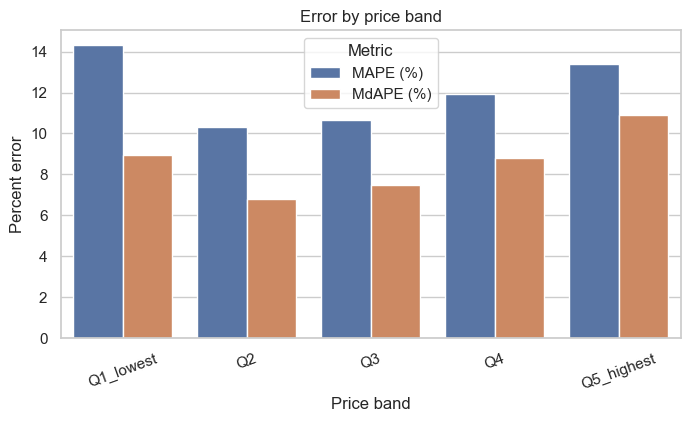

In [4]:
bands = metrics.query("section == 'main_price_band'").copy()
bands["MAPE (%)"] = bands["mape"] * 100
bands["MdAPE (%)"] = bands["mdape"] * 100

long_bands = bands.melt(
    id_vars=["price_segment"],
    value_vars=["MAPE (%)", "MdAPE (%)"],
    var_name="Metric",
    value_name="Percent error",
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(
    data=long_bands,
    x="price_segment",
    y="Percent error",
    hue="Metric",
    ax=ax,
)
ax.set_title("Error by price band")
ax.set_xlabel("Price band")
ax.set_ylabel("Percent error")
ax.tick_params(axis="x", rotation=20)
plt.show()

**Interpretation**

- Middle-price bands are the safest model-supported pricing zone because their typical percentage errors are lower.
- The highest band is riskier because luxury and unusual homes are harder to price from standard listing features.
- The lowest band also needs review because a smaller dollar miss can become a large percentage error.

## 6. Error Risk Distribution

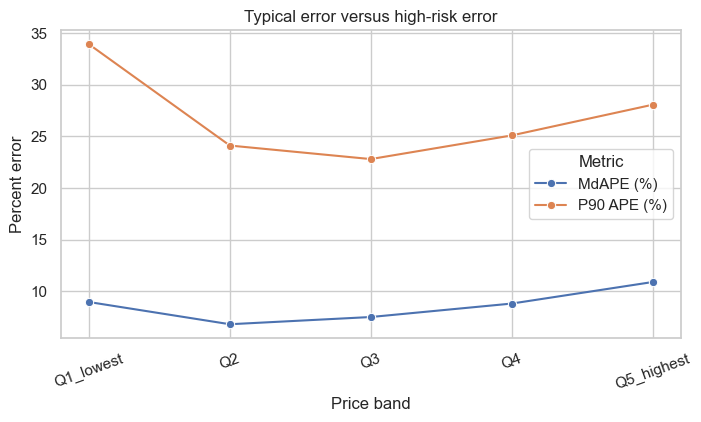

In [5]:
risk_view = bands[["price_segment", "mdape", "p90_ape"]].copy()
risk_view["MdAPE (%)"] = risk_view["mdape"] * 100
risk_view["P90 APE (%)"] = risk_view["p90_ape"] * 100

risk_long = risk_view.melt(
    id_vars="price_segment",
    value_vars=["MdAPE (%)", "P90 APE (%)"],
    var_name="Metric",
    value_name="Percent error",
)

fig, ax = plt.subplots(figsize=(8, 4))
sns.lineplot(
    data=risk_long,
    x="price_segment",
    y="Percent error",
    hue="Metric",
    marker="o",
    ax=ax,
)
ax.set_title("Typical error versus high-risk error")
ax.set_xlabel("Price band")
ax.set_ylabel("Percent error")
ax.tick_params(axis="x", rotation=20)
plt.show()

**Interpretation**

- MdAPE shows the normal pricing miss.
- P90 APE shows the high-risk tail where model output should not be trusted alone.
- Large gaps between MdAPE and P90 APE identify segments where manual review is most important.

## 7. Decision Implication

In [6]:
print(
    f"June in-range test: R2={summary['overall_r2']:.3f}, "
    f"MAPE={summary['overall_mape']:.1%}, "
    f"MdAPE={summary['overall_mdape']:.1%}."
)
print(
    f"Most reliable band: {summary['best_segment']} "
    f"(MdAPE={summary['best_mdape']:.1%})."
)
print(
    f"Highest-risk band: {summary['worst_segment']} "
    f"(MdAPE={summary['worst_mdape']:.1%}, "
    f"MAPE={summary['worst_mape']:.1%})."
)

June in-range test: R2=0.911, MAPE=12.2%, MdAPE=8.5%.
Most reliable band: Q2 (MdAPE=6.8%).
Highest-risk band: Q5_highest (MdAPE=10.9%, MAPE=13.4%).


**Pricing-review rule**

- Use model predictions as a pricing check for typical middle-market homes.
- Require manual review when a home is in the highest price band, the lowest price band, or has unusual property characteristics.
- Do not use the model as an automatic final price setter.

## 8. Robustness Check

In [7]:
robustness = metrics.query("section == 'robustness'").copy()
display(
    robustness.assign(
        r2=robustness["r2"].round(3),
        mape=(robustness["mape"] * 100).round(2),
        mdape=(robustness["mdape"] * 100).round(2),
        p90_ape=(robustness["p90_ape"] * 100).round(2),
        mae=robustness["mae"].round(0),
        rmse=robustness["rmse"].round(0),
    )
)

,section,price_segment,rows,median_close_price,r2,mae,rmse,mape,mdape,p90_ape,median_error
6,robustness,Full June,12851,NaN,0.678,208249.0,871792.0,13.81,8.67,28.57,1985.4375


**Interpretation**

Full June is an operational robustness check. It includes records outside the train-defined in-range population, so it should not replace the main Week 8 result or be used to select the model.

## 9. Limitations

- This notebook regenerates June row-level predictions from the Week 7 locked XGBoost setup.
- The main result is **June in-range**. Full June is robustness only.
- The evaluation is based on one June test month, so it should be monitored again as new months arrive.
- Price-band results explain model reliability, not causal market behavior.
- Percentage error can look severe for lower-priced homes even when dollar error is moderate.

## 10. Final Takeaway

On the comparable **June in-range** population, the model is strong enough to support **pricing review**, especially for middle-market homes. It is not strong enough to replace human judgment for unusual, low-price, or high-price transactions.

Supporting file: `outputs/week8_evaluation/metrics_summary.csv`.